In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [5]:
SM101K07L_data = np.loadtxt('SM101K07L_Model.csv', delimiter=',', skiprows=1)



In [277]:
last_curve_index = np.where(SM101K07L_data[:, 0] == 5)[0][0] + 1
row_num_total = SM101K07L_data.shape[0]
curve_num = row_num_total / (last_curve_index+1)
last_curve_index

np.int64(62)

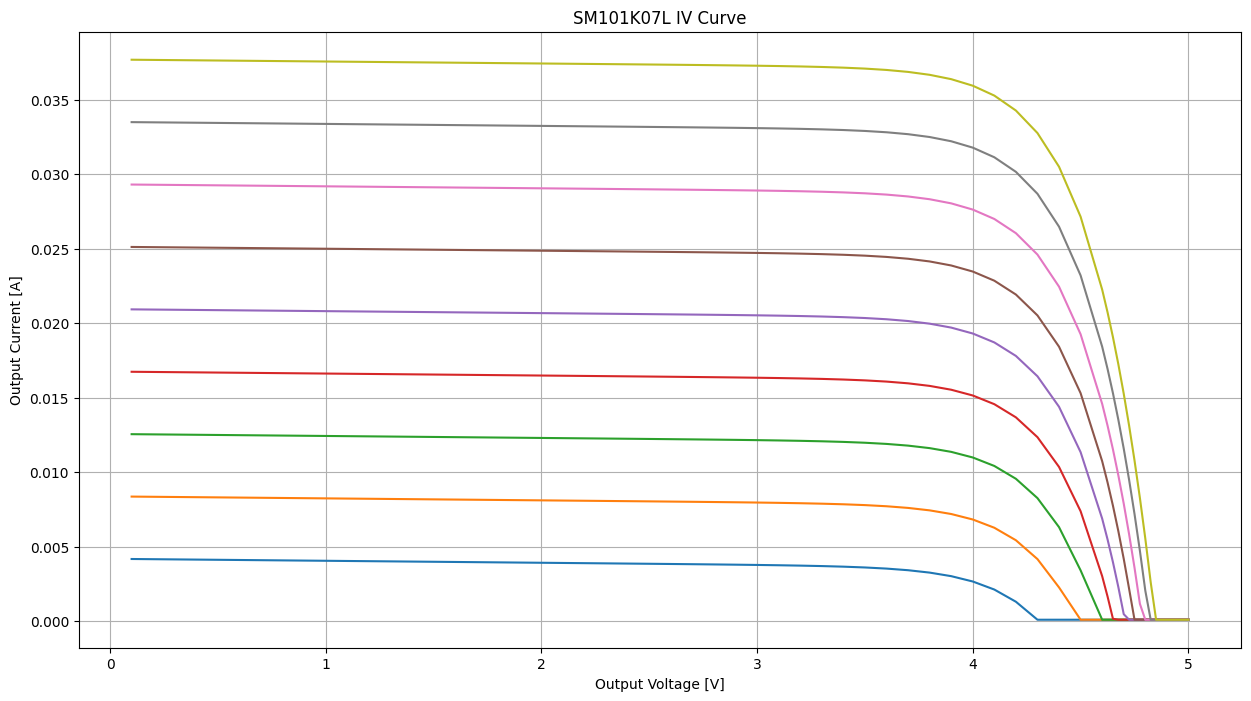

In [80]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

for i in range(0, int(curve_num)):
    ax.plot(SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),0], SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),1])

ax.set_xlabel('Output Voltage [V]')
ax.set_ylabel('Output Current [A]')
ax.set_title('SM101K07L IV Curve')
ax.grid()
#ax.loglog()

[]

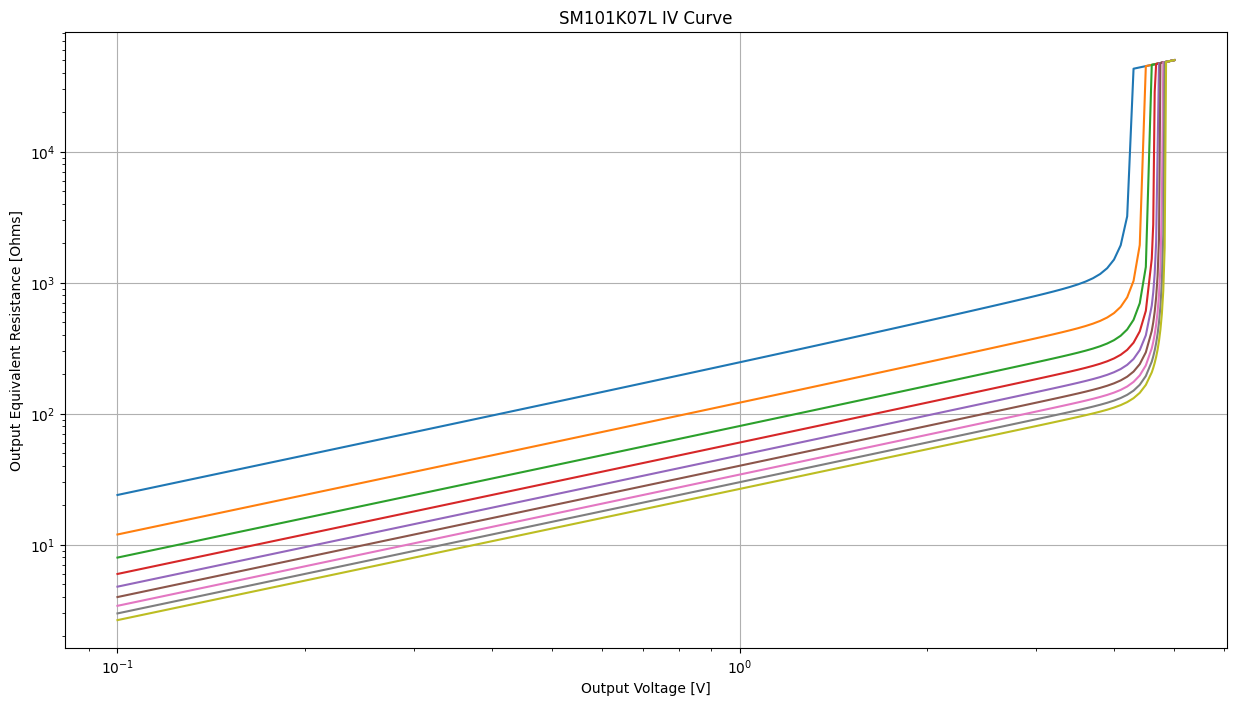

In [79]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

for i in range(0, int(curve_num)):
    ax.plot(SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),0], SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),0] / SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),1])

ax.set_xlabel('Output Voltage [V]')
ax.set_ylabel('Output Equivalent Resistance [Ohms]')
ax.set_title('SM101K07L IV Curve')
ax.grid()
ax.loglog()

In [143]:
def find_x_max(vol_vec, cur_vec):
    ind = np.where(cur_vec == .1e-3)[0][0]
   # print(ind)
    return vol_vec[ind-1]

def indv_curv(x_vec, y_vec, num):
    i = num
    
    ret_x_vec = SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),0]
    ret_y_vec = SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),0] / SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),1]
    ret_i_vec = SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),1]
    
    return ret_x_vec, ret_y_vec, ret_i_vec

    

In [145]:
i=5
a = find_x_max(SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),0], SM101K07L_data[(i*last_curve_index):((i+1)*last_curve_index),1])
a

np.float64(4.75)

In [270]:
# Example data with mismatched domains

x1, y1, i1 = indv_curv(SM101K07L_data[:,0], SM101K07L_data[:,1], 5)
x2, y2, i2 = indv_curv(SM101K07L_data[:,0], SM101K07L_data[:,1], 6)

# Define interpolation factor (e.g., alpha = 0.5)
alpha = 0.5

# Find midpoint x_max for normalization
#x_max1 = max(x1)
#x_max2 = max(x2)
#x_max_new = (x_max1 + x_max2) / 2

x_max1 = find_x_max(x1, i1)
x_max2 = find_x_max(x2, i2)
#x_max_new = (x_max1 + x_max2) * alpha
x_max_new = x_max1 + (x_max2 - x_max1) * alpha



In [271]:

# Normalize x-values to [0, 1] for both curves
x1_norm = x1 / x_max1
x2_norm = x2 / x_max2

# Define a common normalized grid
#common_x_norm = np.linspace(0, 1, 62)

# Interpolate y-values on the normalized grid
interp1_norm = interp1d(x1_norm, y1, kind='linear', fill_value="extrapolate")
interp2_norm = interp1d(x2_norm, y2, kind='linear', fill_value="extrapolate")

y1_interp_norm = interp1_norm(x1_norm)
y2_interp_norm = interp2_norm(x1_norm)

# Blend the y-values
y_interp_norm = (1 - alpha) * y1 + alpha * y2_interp_norm

# Scale the normalized x-values back to the new domain
common_x_new = x1_norm * x_max_new

ymix = (1 - alpha) * y1 + alpha * y2

In [276]:
y2_interp_norm.shape[0]

62

In [275]:
x2_norm

array([0.02083333, 0.04166667, 0.0625    , 0.08333333, 0.10416667,
       0.125     , 0.14583333, 0.16666667, 0.1875    , 0.20833333,
       0.22916667, 0.25      , 0.27083333, 0.29166667, 0.3125    ,
       0.33333333, 0.35416667, 0.375     , 0.39583333, 0.41666667,
       0.4375    , 0.45833333, 0.47916667, 0.5       , 0.52083333,
       0.54166667, 0.5625    , 0.58333333, 0.60416667, 0.625     ,
       0.64583333, 0.66666667, 0.6875    , 0.70833333, 0.72916667,
       0.75      , 0.77083333, 0.79166667, 0.8125    , 0.83333333,
       0.85416667, 0.875     , 0.89583333, 0.91666667, 0.9375    ,
       0.95833333, 0.96354167, 0.96875   , 0.97395833, 0.97916667,
       0.984375  , 0.98958333, 0.99479167, 1.        , 1.00520833,
       1.01041667, 1.015625  , 1.02083333, 1.02604167, 1.03125   ,
       1.03645833, 1.04166667])

In [261]:
y1_interp_norm

array([3.98061317e+00, 7.96544195e+00, 1.19544931e+01, 1.59477732e+01,
       1.99452892e+01, 2.39470477e+01, 2.79530557e+01, 3.19633199e+01,
       3.59778475e+01, 3.99966453e+01, 4.40197209e+01, 4.80470818e+01,
       5.20787362e+01, 5.61146931e+01, 6.01549629e+01, 6.41995579e+01,
       6.82484943e+01, 7.23017933e+01, 7.63594851e+01, 8.04216140e+01,
       8.44882464e+01, 8.85594845e+01, 9.26354869e+01, 9.67165023e+01,
       1.00802922e+02, 1.04895364e+02, 1.08994807e+02, 1.13102796e+02,
       1.17221780e+02, 1.21355635e+02, 1.25510497e+02, 1.29696079e+02,
       1.33927766e+02, 1.38229948e+02, 1.42641357e+02, 1.47223687e+02,
       1.52075683e+02, 1.57356643e+02, 1.63326754e+02, 1.70419276e+02,
       1.79377593e+02, 1.91537658e+02, 2.09479123e+02, 2.38779542e+02,
       2.93961186e+02, 4.28238951e+02, 4.96629687e+02, 5.99949821e+02,
       7.73295381e+02, 1.12238086e+03, 2.18100262e+03, 4.75000000e+04,
       4.77500000e+04, 4.80000000e+04, 4.82500000e+04, 4.85000000e+04,
      

[]

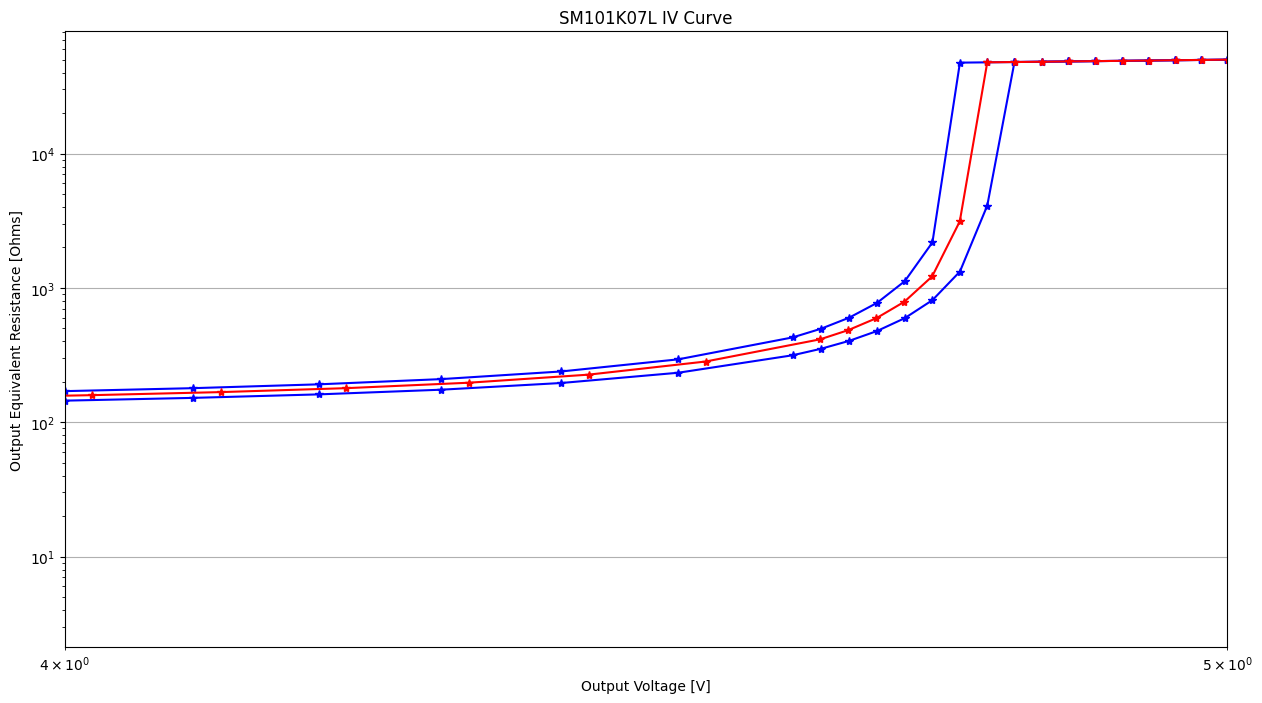

In [273]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

ax.plot(x1, y1, 'b-*')
ax.plot(x2, y2, 'b-*')
ax.plot(common_x_new, y_interp_norm, 'r-*')
#ax.plot(common_x_new, ymix, 'g-*')

ax.set_xlabel('Output Voltage [V]')
ax.set_ylabel('Output Equivalent Resistance [Ohms]')
ax.set_title('SM101K07L IV Curve')
ax.grid()
ax.set_xlim(4,5)
ax.loglog()

In [188]:
# Example 1D array with floats
array_1d = np.array([1.123456, 2.654321, 3.141592, 4.987654, 5.123456,
                     6.789012, 7.111213, 8.141516, 9.171819, 10.202122,
                     11.232425, 12.262728, 13.292930])

# Format the 1D array for C-style syntax with 3 decimal places and line breaks
def format_1d_for_c(array, values_per_line=10):
    formatted_values = [f"{value:.3f}" for value in array]
    lines = []
    for i in range(0, len(formatted_values), values_per_line):
        # Group numbers in chunks of `values_per_line`
        lines.append(", ".join(formatted_values[i:i + values_per_line]))
    return "{\n    " + ",\n    ".join(lines) + "\n};"

# Print the formatted array
formatted_array = format_1d_for_c(array_1d)
print("float lookup_table[] = " + formatted_array)

float lookup_table[] = {
    1.123, 2.654, 3.142, 4.988, 5.123, 6.789, 7.111, 8.142, 9.172, 10.202,
    11.232, 12.263, 13.293
};


In [190]:
array_1d = SM101K07L_data[:,0] / SM101K07L_data[:,1]
print("int lookup_table[] = " + format_1d_for_c(array_1d))

int lookup_table[] = {
    23.947, 48.047, 72.302, 96.712, 121.280, 146.007, 170.894, 195.943, 221.157, 246.535,
    272.080, 297.794, 323.679, 349.735, 375.966, 402.372, 428.957, 455.721, 482.669, 509.803,
    537.127, 564.646, 592.369, 620.305, 648.472, 676.894, 705.610, 734.681, 764.202, 794.327,
    825.298, 857.507, 891.584, 928.559, 970.139, 1019.217, 1080.881, 1164.590, 1289.519, 1500.359,
    1929.226, 3211.604, 43000.000, 44000.000, 45000.000, 46000.000, 46250.000, 46500.000, 46750.000, 47000.000,
    47250.000, 47500.000, 47750.000, 48000.000, 48250.000, 48500.000, 48750.000, 49000.000, 49250.000, 49500.000,
    49750.000, 50000.000, 11.954, 23.947, 35.978, 48.047, 60.155, 72.302, 84.487, 96.712,
    108.976, 121.280, 133.623, 146.007, 158.430, 170.894, 183.399, 195.944, 208.531, 221.159,
    233.828, 246.541, 259.296, 272.095, 284.940, 297.833, 310.777, 323.778, 336.845, 349.991,
    363.238, 376.620, 390.191, 404.037, 418.297, 433.192, 449.077, 466.534, 486.528, 510.699,
  

In [192]:
array_1d = SM101K07L_data[:,0]
print("int lookup_table[] = " + format_1d_for_c(array_1d))

int lookup_table[] = {
    0.100, 0.200, 0.300, 0.400, 0.500, 0.600, 0.700, 0.800, 0.900, 1.000,
    1.100, 1.200, 1.300, 1.400, 1.500, 1.600, 1.700, 1.800, 1.900, 2.000,
    2.100, 2.200, 2.300, 2.400, 2.500, 2.600, 2.700, 2.800, 2.900, 3.000,
    3.100, 3.200, 3.300, 3.400, 3.500, 3.600, 3.700, 3.800, 3.900, 4.000,
    4.100, 4.200, 4.300, 4.400, 4.500, 4.600, 4.625, 4.650, 4.675, 4.700,
    4.725, 4.750, 4.775, 4.800, 4.825, 4.850, 4.875, 4.900, 4.925, 4.950,
    4.975, 5.000, 0.100, 0.200, 0.300, 0.400, 0.500, 0.600, 0.700, 0.800,
    0.900, 1.000, 1.100, 1.200, 1.300, 1.400, 1.500, 1.600, 1.700, 1.800,
    1.900, 2.000, 2.100, 2.200, 2.300, 2.400, 2.500, 2.600, 2.700, 2.800,
    2.900, 3.000, 3.100, 3.200, 3.300, 3.400, 3.500, 3.600, 3.700, 3.800,
    3.900, 4.000, 4.100, 4.200, 4.300, 4.400, 4.500, 4.600, 4.625, 4.650,
    4.675, 4.700, 4.725, 4.750, 4.775, 4.800, 4.825, 4.850, 4.875, 4.900,
    4.925, 4.950, 4.975, 5.000, 0.100, 0.200, 0.300, 0.400, 0.500, 0.600,
    0.700, 0.80

In [199]:
array_1d = np.zeros(10)
for i in range(0, 10):
    x1, y1, i1 = indv_curv(SM101K07L_data[:,0], SM101K07L_data[:,1], i)
    array_1d[i] = find_x_max(x1, i1)
print("int lookup_table[] = " + format_1d_for_c(array_1d))

int lookup_table[] = {
    4.300, 4.500, 4.600, 4.675, 4.725, 4.750, 4.800, 4.825, 4.850, 4.875
};
